In [2]:
import json

match_id = "NA1_5612950221"   # use one of your real match IDs

with open(f"data/raw/matches/{match_id}.json", "r") as f:
    match_data = json.load(f)

with open(f"data/raw/timelines/{match_id}.json", "r") as f:
    timeline_data = json.load(f)

In [3]:
participants = match_data["info"]["participants"]

blue_ids = [
    p["participantId"]
    for p in participants
    if p["teamId"] == 100
]

red_ids = [
    p["participantId"]
    for p in participants
    if p["teamId"] == 200
]

print("Blue:", blue_ids)
print("Red:", red_ids)

Blue: [1, 2, 3, 4, 5]
Red: [6, 7, 8, 9, 10]


In [4]:
participants = match_data["info"]["participants"]
frames = timeline_data["info"]["frames"]

In [5]:
print(match_data["metadata"]["matchId"])
print(len(match_data["info"]["participants"]))
print(len(timeline_data["info"]["frames"]))

NA1_5612950221
10
34


In [6]:
participants = match_data["info"]["participants"]

blue_ids = [
    p["participantId"]
    for p in participants
    if p["teamId"] == 100
]

red_ids = [
    p["participantId"]
    for p in participants
    if p["teamId"] == 200
]

print("Blue:", blue_ids)
print("Red:", red_ids)

Blue: [1, 2, 3, 4, 5]
Red: [6, 7, 8, 9, 10]


In [7]:
blue_win = int(
    any(
        p["win"]
        for p in participants
        if p["teamId"] == 100
    )
)

print("Blue won:", blue_win)

Blue won: 1


In [8]:
import pandas as pd

frames = timeline_data["info"]["frames"]

rows = []

for frame in frames:
    minute = frame["timestamp"] / 60000

    pf = frame["participantFrames"]

    blue_gold = 0
    red_gold = 0

    blue_xp = 0
    red_xp = 0

    blue_cs = 0
    red_cs = 0

    for pid in blue_ids:
        player = pf[str(pid)]

        blue_gold += player["totalGold"]
        blue_xp += player["xp"]
        blue_cs += (
            player["minionsKilled"]
            + player["jungleMinionsKilled"]
        )

    for pid in red_ids:
        player = pf[str(pid)]

        red_gold += player["totalGold"]
        red_xp += player["xp"]
        red_cs += (
            player["minionsKilled"]
            + player["jungleMinionsKilled"]
        )

    rows.append({
        "match_id": match_data["metadata"]["matchId"],
        "minute": minute,

        "blue_gold": blue_gold,
        "red_gold": red_gold,
        "gold_diff": blue_gold - red_gold,

        "blue_xp": blue_xp,
        "red_xp": red_xp,
        "xp_diff": blue_xp - red_xp,

        "blue_cs": blue_cs,
        "red_cs": red_cs,
        "cs_diff": blue_cs - red_cs,

        "blue_win": blue_win
    })

df = pd.DataFrame(rows)

In [10]:
df.head(10)

,match_id,minute,blue_gold,red_gold,gold_diff,blue_xp,red_xp,xp_diff,blue_cs,red_cs,cs_diff,blue_win
0,NA1_5612950221,0.000000,2500,2500,0,0,0,0,0,0,0,1
1,NA1_5612950221,1.000283,2505,3055,-550,0,26,-26,0,0,0,1
2,NA1_5612950221,2.000517,4096,4737,-641,2118,2288,-170,30,34,-4,1
3,NA1_5612950221,3.000583,5697,6129,-432,4539,4657,-118,74,72,2,1
4,NA1_5612950221,4.000583,8097,7990,107,6774,6579,195,103,98,5,1
5,NA1_5612950221,5.000850,9574,10033,-459,8652,8816,-164,131,128,3,1
6,NA1_5612950221,6.001333,10971,11907,-936,10275,11149,-874,161,160,1,1
7,NA1_5612950221,7.001383,13000,13966,-966,13117,13512,-395,193,184,9,1
8,NA1_5612950221,8.001800,14508,15564,-1056,14671,15617,-946,224,213,11,1
9,NA1_5612950221,9.003233,17585,18042,-457,17805,18869,-1064,261,261,0,1


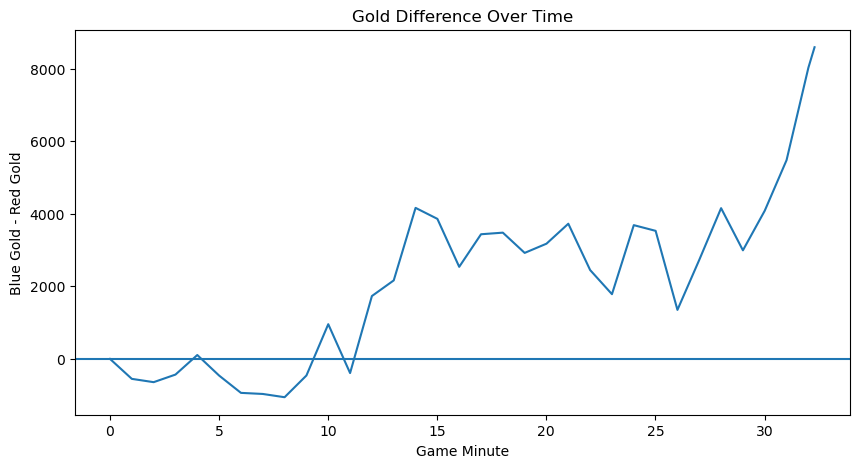

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(df["minute"], df["gold_diff"])
plt.axhline(0)

plt.xlabel("Game Minute")
plt.ylabel("Blue Gold - Red Gold")
plt.title("Gold Difference Over Time")

plt.show()

In [20]:
blue_kills = 0
red_kills = 0

blue_tower_destroyed = 0
red_tower_destroyed = 0

blue_dragons = 0
red_dragons = 0

blue_heralds = 0
red_heralds = 0

blue_barons = 0
red_barons = 0

blue_elders = 0
red_elders = 0

rows = []

INHIB_RESPAWN_MS = 5 * 60 * 1000
NEXUS_TURRET_RESPAWN_MS = 3 * 60 * 1000

# Each list stores the time when a currently-dead structure will respawn
blue_inhib_respawns = []
red_inhib_respawns = []

blue_nexus_respawns = []
red_nexus_respawns = []

for frame in frames:
    current_time = frame["timestamp"]
    minute = current_time/ 60000
    pf = frame["participantFrames"]

        # Remove structures whose respawn timer has finished
    blue_inhib_respawns = [
        t for t in blue_inhib_respawns
        if t > current_time
    ]

    red_inhib_respawns = [
        t for t in red_inhib_respawns
        if t > current_time
    ]

    blue_nexus_respawns = [
        t for t in blue_nexus_respawns
        if t > current_time
    ]

    red_nexus_respawns = [
        t for t in red_nexus_respawns
        if t > current_time
    ]

    # -------------------------
    # Update cumulative events
    # -------------------------
    for event in frame["events"]:

        if event["type"] == "CHAMPION_KILL":
            killer_id = event.get("killerId", 0)

            if killer_id in blue_ids:
                blue_kills += 1
            elif killer_id in red_ids:
                red_kills += 1

        elif event["type"] == "BUILDING_KILL":

            team_id = event.get("teamId")
            building_type = event.get("buildingType")
            tower_type = event.get("towerType")
            event_time = event["timestamp"]

            # -------------------------
            # INHIBITOR DESTROYED
            # -------------------------
            if building_type == "INHIBITOR_BUILDING":

                # Blue inhibitor died
                if team_id == 100:
                    blue_inhib_respawns.append(
                        event_time + INHIB_RESPAWN_MS
                    )

                # Red inhibitor died
                elif team_id == 200:
                    red_inhib_respawns.append(
                        event_time + INHIB_RESPAWN_MS
                    )

            # -------------------------
            # TOWER DESTROYED
            # -------------------------
            elif building_type == "TOWER_BUILDING":

                # Nexus turrets need special treatment because they respawn
                if tower_type == "NEXUS_TURRET":

                    # Blue Nexus turret died
                    if team_id == 100:
                        blue_nexus_respawns.append(
                            event_time + NEXUS_TURRET_RESPAWN_MS
                        )

                    # Red Nexus turret died
                    elif team_id == 200:
                        red_nexus_respawns.append(
                            event_time + NEXUS_TURRET_RESPAWN_MS
                        )

                # Normal towers
                else:

                    # Red tower died -> Blue destroyed it
                    if team_id == 200:
                        blue_tower_destroyed += 1

                    # Blue tower died -> Red destroyed it
                    elif team_id == 100:
                        red_tower_destroyed += 1

        elif event["type"] == "ELITE_MONSTER_KILL":

            killer_team = event.get("killerTeamId")
            monster = event.get("monsterType")
            monster_subtype = event.get("monsterSubType")

            if monster == "DRAGON":

                # Elder should NOT count toward elemental dragon stacks
                if monster_subtype == "ELDER_DRAGON":

                    if killer_team == 100:
                        blue_elders += 1

                    elif killer_team == 200:
                        red_elders += 1

                # Regular elemental dragon
                else:

                    if killer_team == 100:
                        blue_dragons += 1

                    elif killer_team == 200:
                        red_dragons += 1


            elif monster == "RIFTHERALD":

                if killer_team == 100:
                    blue_heralds += 1

                elif killer_team == 200:
                    red_heralds += 1


            elif monster == "BARON_NASHOR":

                if killer_team == 100:
                    blue_barons += 1

                elif killer_team == 200:
                    red_barons += 1


    blue_inhibs_alive = 3 - len(blue_inhib_respawns)
    red_inhibs_alive = 3 - len(red_inhib_respawns)

    blue_nexus_turrets_alive = 2 - len(blue_nexus_respawns)
    red_nexus_turrets_alive = 2 - len(red_nexus_respawns)

    # -------------------------
    # Team totals from frame
    # -------------------------
    blue_gold = 0
    red_gold = 0

    blue_xp = 0
    red_xp = 0

    blue_cs = 0
    red_cs = 0

    for pid in blue_ids:
        player = pf[str(pid)]
        blue_gold += player["totalGold"]
        blue_xp += player["xp"]
        blue_cs += player["minionsKilled"] + player["jungleMinionsKilled"]

    for pid in red_ids:
        player = pf[str(pid)]
        red_gold += player["totalGold"]
        red_xp += player["xp"]
        red_cs += player["minionsKilled"] + player["jungleMinionsKilled"]

    rows.append({
        "match_id": match_data["metadata"]["matchId"],
        "minute": minute,

        # Economy
        "gold_diff": blue_gold - red_gold,
        "xp_diff": blue_xp - red_xp,
        "cs_diff": blue_cs - red_cs,

        # Combat
        "blue_kills": blue_kills,
        "red_kills": red_kills,
        "kill_diff": blue_kills - red_kills,

        # Towers
        "blue_towers_destroyed": blue_towers_destroyed,
        "red_towers_destroyed": red_towers_destroyed,
        "tower_diff": blue_towers_destroyed - red_towers_destroyed,

        # Dragons
        "blue_dragons": blue_dragons,
        "red_dragons": red_dragons,
        "dragon_diff": blue_dragons - red_dragons,

        "blue_dragons_to_soul": max(0, 4 - blue_dragons),
        "red_dragons_to_soul": max(0, 4 - red_dragons),

        "blue_has_soul": int(blue_dragons >= 4),
        "red_has_soul": int(red_dragons >= 4),

        # Elder
        "blue_elders": blue_elders,
        "red_elders": red_elders,

        # Herald
        "blue_heralds": blue_heralds,
        "red_heralds": red_heralds,

        # Baron
        "blue_barons": blue_barons,
        "red_barons": red_barons,

        # Current base state
        "blue_inhibs_alive": blue_inhibs_alive,
        "red_inhibs_alive": red_inhibs_alive,

        "blue_nexus_turrets_alive": blue_nexus_turrets_alive,
        "red_nexus_turrets_alive": red_nexus_turrets_alive,

        # Target
        "blue_win": blue_win
    })

df = pd.DataFrame(rows)

In [28]:
pd.set_option("display.max_columns", None)
df.head(1)

,match_id,minute,gold_diff,xp_diff,cs_diff,blue_kills,red_kills,kill_diff,blue_towers_destroyed,red_towers_destroyed,tower_diff,blue_dragons,red_dragons,dragon_diff,blue_dragons_to_soul,red_dragons_to_soul,blue_has_soul,red_has_soul,blue_elders,red_elders,blue_heralds,red_heralds,blue_barons,red_barons,blue_inhibs_alive,red_inhibs_alive,blue_nexus_turrets_alive,red_nexus_turrets_alive,blue_win
0,NA1_5612950221,0.0,0,0,0,0,0,0,0,0,0,0,0,0,4,4,0,0,0,0,0,0,0,0,3,3,2,2,1


In [29]:
import pandas as pd


def process_match(match_data, timeline_data):

    # --------------------------------------------------
    # Match-level information
    # --------------------------------------------------
    match_id = match_data["metadata"]["matchId"]
    game_version = match_data["info"]["gameVersion"]
    game_duration = match_data["info"]["gameDuration"]

    participants = match_data["info"]["participants"]
    frames = timeline_data["info"]["frames"]


    # --------------------------------------------------
    # Identify Blue and Red participants
    # --------------------------------------------------
    blue_ids = [
        p["participantId"]
        for p in participants
        if p["teamId"] == 100
    ]

    red_ids = [
        p["participantId"]
        for p in participants
        if p["teamId"] == 200
    ]


    # --------------------------------------------------
    # Determine winner
    # --------------------------------------------------
    blue_win = int(
        any(
            p["win"]
            for p in participants
            if p["teamId"] == 100
        )
    )


    # --------------------------------------------------
    # Cumulative event counters
    # --------------------------------------------------
    blue_kills = 0
    red_kills = 0

    blue_towers_destroyed = 0
    red_towers_destroyed = 0

    blue_dragons = 0
    red_dragons = 0

    blue_heralds = 0
    red_heralds = 0

    blue_barons = 0
    red_barons = 0

    blue_elders = 0
    red_elders = 0


    # --------------------------------------------------
    # Respawning structure state
    # --------------------------------------------------
    INHIB_RESPAWN_MS = 5 * 60 * 1000
    NEXUS_TURRET_RESPAWN_MS = 3 * 60 * 1000

    blue_inhib_respawns = []
    red_inhib_respawns = []

    blue_nexus_respawns = []
    red_nexus_respawns = []


    # --------------------------------------------------
    # Output rows
    # --------------------------------------------------
    rows = []


    # --------------------------------------------------
    # Process every timeline frame
    # --------------------------------------------------
    for frame in frames:

        current_time = frame["timestamp"]
        minute = current_time / 60000

        pf = frame["participantFrames"]


        # ----------------------------------------------
        # Remove structures whose respawn timer finished
        # ----------------------------------------------
        blue_inhib_respawns = [
            t for t in blue_inhib_respawns
            if t > current_time
        ]

        red_inhib_respawns = [
            t for t in red_inhib_respawns
            if t > current_time
        ]

        blue_nexus_respawns = [
            t for t in blue_nexus_respawns
            if t > current_time
        ]

        red_nexus_respawns = [
            t for t in red_nexus_respawns
            if t > current_time
        ]


        # ----------------------------------------------
        # Process events in this frame
        # ----------------------------------------------
        for event in frame["events"]:

            event_type = event["type"]


            # ==========================================
            # Champion kills
            # ==========================================
            if event_type == "CHAMPION_KILL":

                killer_id = event.get("killerId", 0)

                if killer_id in blue_ids:
                    blue_kills += 1

                elif killer_id in red_ids:
                    red_kills += 1


            # ==========================================
            # Buildings
            # ==========================================
            elif event_type == "BUILDING_KILL":

                team_id = event.get("teamId")
                building_type = event.get("buildingType")
                tower_type = event.get("towerType")
                event_time = event["timestamp"]


                # --------------------------------------
                # Inhibitor
                # --------------------------------------
                if building_type == "INHIBITOR_BUILDING":

                    # Blue inhibitor destroyed
                    if team_id == 100:
                        blue_inhib_respawns.append(
                            event_time + INHIB_RESPAWN_MS
                        )

                    # Red inhibitor destroyed
                    elif team_id == 200:
                        red_inhib_respawns.append(
                            event_time + INHIB_RESPAWN_MS
                        )


                # --------------------------------------
                # Tower
                # --------------------------------------
                elif building_type == "TOWER_BUILDING":

                    # Nexus turret
                    if tower_type == "NEXUS_TURRET":

                        # Blue Nexus turret destroyed
                        if team_id == 100:
                            blue_nexus_respawns.append(
                                event_time + NEXUS_TURRET_RESPAWN_MS
                            )

                        # Red Nexus turret destroyed
                        elif team_id == 200:
                            red_nexus_respawns.append(
                                event_time + NEXUS_TURRET_RESPAWN_MS
                            )

                    # Normal tower
                    else:

                        # Red tower died -> Blue destroyed it
                        if team_id == 200:
                            blue_towers_destroyed += 1

                        # Blue tower died -> Red destroyed it
                        elif team_id == 100:
                            red_towers_destroyed += 1


            # ==========================================
            # Neutral objectives
            # ==========================================
            elif event_type == "ELITE_MONSTER_KILL":

                killer_team = event.get("killerTeamId")
                monster = event.get("monsterType")
                monster_subtype = event.get("monsterSubType")


                # --------------------------------------
                # Dragons
                # --------------------------------------
                if monster == "DRAGON":

                    # Elder Dragon
                    if monster_subtype == "ELDER_DRAGON":

                        if killer_team == 100:
                            blue_elders += 1

                        elif killer_team == 200:
                            red_elders += 1


                    # Normal elemental dragon
                    else:

                        if killer_team == 100:
                            blue_dragons += 1

                        elif killer_team == 200:
                            red_dragons += 1


                # --------------------------------------
                # Rift Herald
                # --------------------------------------
                elif monster == "RIFTHERALD":

                    if killer_team == 100:
                        blue_heralds += 1

                    elif killer_team == 200:
                        red_heralds += 1


                # --------------------------------------
                # Baron
                # --------------------------------------
                elif monster == "BARON_NASHOR":

                    if killer_team == 100:
                        blue_barons += 1

                    elif killer_team == 200:
                        red_barons += 1


        # --------------------------------------------------
        # Current structures alive
        # --------------------------------------------------
        blue_inhibs_alive = max(
            0,
            3 - len(blue_inhib_respawns)
        )

        red_inhibs_alive = max(
            0,
            3 - len(red_inhib_respawns)
        )

        blue_nexus_turrets_alive = max(
            0,
            2 - len(blue_nexus_respawns)
        )

        red_nexus_turrets_alive = max(
            0,
            2 - len(red_nexus_respawns)
        )


        # --------------------------------------------------
        # Team totals from participant frames
        # --------------------------------------------------
        blue_gold = 0
        red_gold = 0

        blue_xp = 0
        red_xp = 0

        blue_cs = 0
        red_cs = 0


        for pid in blue_ids:

            player = pf[str(pid)]

            blue_gold += player["totalGold"]
            blue_xp += player["xp"]

            blue_cs += (
                player["minionsKilled"]
                + player["jungleMinionsKilled"]
            )


        for pid in red_ids:

            player = pf[str(pid)]

            red_gold += player["totalGold"]
            red_xp += player["xp"]

            red_cs += (
                player["minionsKilled"]
                + player["jungleMinionsKilled"]
            )


        # --------------------------------------------------
        # Save current game state
        # --------------------------------------------------
        rows.append({

            # Match metadata
            "match_id": match_id,
            "minute": minute,
            "game_version": game_version,
            "game_duration": game_duration,

            # Economy
            "blue_gold": blue_gold,
            "red_gold": red_gold,
            "gold_diff": blue_gold - red_gold,

            "blue_xp": blue_xp,
            "red_xp": red_xp,
            "xp_diff": blue_xp - red_xp,

            "blue_cs": blue_cs,
            "red_cs": red_cs,
            "cs_diff": blue_cs - red_cs,


            # Combat
            "blue_kills": blue_kills,
            "red_kills": red_kills,
            "kill_diff": blue_kills - red_kills,


            # Towers
            "blue_towers_destroyed": blue_towers_destroyed,
            "red_towers_destroyed": red_towers_destroyed,
            "tower_diff": (
                blue_towers_destroyed
                - red_towers_destroyed
            ),


            # Dragons
            "blue_dragons": blue_dragons,
            "red_dragons": red_dragons,

            "dragon_diff": (
                blue_dragons
                - red_dragons
            ),

            "blue_dragons_to_soul": max(
                0,
                4 - blue_dragons
            ),

            "red_dragons_to_soul": max(
                0,
                4 - red_dragons
            ),

            "blue_has_soul": int(
                blue_dragons >= 4
            ),

            "red_has_soul": int(
                red_dragons >= 4
            ),


            # Elder
            "blue_elders": blue_elders,
            "red_elders": red_elders,


            # Herald
            "blue_heralds": blue_heralds,
            "red_heralds": red_heralds,


            # Baron
            "blue_barons": blue_barons,
            "red_barons": red_barons,


            # Current base state
            "blue_inhibs_alive": blue_inhibs_alive,
            "red_inhibs_alive": red_inhibs_alive,

            "blue_nexus_turrets_alive":
                blue_nexus_turrets_alive,

            "red_nexus_turrets_alive":
                red_nexus_turrets_alive,


            # Target
            "blue_win": blue_win
        })


    return pd.DataFrame(rows)